In [1]:
import pandas as pd
from collections import defaultdict
import pickle
import pyreadr
import dask.dataframe as dd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
final_ter = pd.read_csv('key_files/final_gen.csv')['sample_name']

In [3]:
dict_blocks = '/home/tbellagio/HapFM/blocks_snpsid_dict.pkl'

with open(dict_blocks, 'rb') as file:
    dict_blocks = pickle.load(file)

reverse_mapping = {item: key for key, values in dict_blocks.items() for item in values}

In [4]:
biovars = [ 'bio1',
    'bio7',
 'bio19',
 'bio13',
 'bio14',
 'bio4',
 'bio10',
 'bio17',
 'bio9',
 'bio3',

 'bio15',
 'bio12',
 'bio18',
 'bio6',
 'bio2',
 'bio8',
 'bio16',
 'bio11',
 'bio5']


In [5]:
from statsmodels.stats.multitest import multipletests

In [ ]:
wza_results

In [ ]:
wza_last_gen/wza_results_lfmm_{biovar}_poly7.csv

In [38]:
biovar = 'bio1'

In [39]:
path_gemma = f'wza_last_gen/gemma_231_wza_{biovar}.csv'

In [40]:
gemma_result = pd.read_csv(path_gemma)


In [41]:
gemma_result

,gene,SNPs,hits,Z,top_candidate_p,Z_pVal
0,1_0,230,0,3.623469,1.0,0.251280
1,1_1,4,0,0.818486,1.0,0.284019
2,1_10,22,0,-0.437598,1.0,0.576945
3,1_100,55,0,-0.759317,1.0,0.585153
4,1_1000,10,0,1.310052,1.0,0.230212
...,...,...,...,...,...,...
16752,5_995,48,0,-1.257352,1.0,0.646831
16753,5_996,3,0,-0.292057,1.0,0.581619
16754,5_997,29,0,-0.023833,1.0,0.507326
16755,5_998,9,0,0.693125,1.0,0.343882


In [37]:
results = {}
for biovar in biovars:

    path_gemma = f'wza_last_gen/gemma_231_wza_{biovar}.csv'
        
    path_lfmm = f'wza_last_gen/wza_results_lfmm_{biovar}_poly7.csv'
        
    gemma_result = pd.read_csv(path_gemma)
        
    lfmm_result = pd.read_csv(path_lfmm)
    
    lfmm_result = lfmm_result.rename(columns = {'gene':'block'})
    lfmm_result['BH_corrected_p'] = multipletests(lfmm_result['Z_pVal'], method='fdr_bh')[1]
    lfmm_result['significant'] = False
    lfmm_result.loc[lfmm_result['BH_corrected_p'] < 0.05, 'significant'] = True
    
    gemma_result = gemma_result.rename(columns = {'gene':'block'})
    gemma_result['BH_corrected_p'] = multipletests(gemma_result['Z_pVal'], method='fdr_bh')[1]
    gemma_result['significant'] = False
    gemma_result.loc[gemma_result['BH_corrected_p'] < 0.05, 'significant'] = True
    
    merged_df = pd.merge(gemma_result, lfmm_result, on = 'block')
    
    # Define significance conditions
    both_significant = merged_df['significant_x'] & merged_df['significant_y']
    print(merged_df[both_significant])
    neither_significant = ~merged_df['significant_x'] & ~merged_df['significant_y']
    only_gemma_significant = merged_df['significant_x'] & ~merged_df['significant_y']
    only_lfmm_significant = ~merged_df['significant_x'] & merged_df['significant_y']
    
    # Count SNPs in each category
    both_count = both_significant.sum()
    neither_count = neither_significant.sum()
    only_gemma_count = only_gemma_significant.sum()
    only_lfmm_count = only_lfmm_significant.sum()

    results[biovar] = [both_count,neither_count, only_gemma_count, only_lfmm_count]

        block  SNPs_x  hits_x        Z_x  top_candidate_p_x  Z_pVal_x  \
5397   2_1265      16       3   8.098473       5.079424e-04  0.000048   
6188    2_199      10       9   7.503037       9.910000e-18  0.000011   
12012  4_2320     556      84  25.563563       1.446291e-69  0.000042   

       BH_corrected_p_x  significant_x  SNPs_y  hits_y        Z_y  \
5397           0.042296           True      16       5   9.626634   
6188           0.018455           True      10       9   8.339289   
12012          0.041610           True     535     155  31.633307   

       top_candidate_p_y  Z_pVal_y  BH_corrected_p_y  significant_y  
5397        3.984317e-07  0.000002          0.010086           True  
6188        9.910000e-18  0.000001          0.007536           True  
12012      6.054142e-174  0.000039          0.044361           True  
Empty DataFrame
Columns: [block, SNPs_x, hits_x, Z_x, top_candidate_p_x, Z_pVal_x, BH_corrected_p_x, significant_x, SNPs_y, hits_y, Z_y, top_candidate

,block,SNPs_x,hits_x,Z_x,top_candidate_p_x,Z_pVal_x,BH_corrected_p_x,significant_x,SNPs_y,hits_y,Z_y,top_candidate_p_y,Z_pVal_y,BH_corrected_p_y,significant_y


In [43]:
results = pd.DataFrame(results).T

In [46]:
results = results.reset_index()

In [47]:


results.columns = ['bio','both_count','neither_count', 'only_gemma_count', 'only_lfmm_count']

In [48]:
results

,bio,both_count,neither_count,only_gemma_count,only_lfmm_count
0,bio1,3,16595,19,12
1,bio7,0,16610,15,4
2,bio19,1,16607,10,11
3,bio13,0,16612,17,0
4,bio14,0,16600,17,12
5,bio4,0,16617,9,3
6,bio10,0,16594,21,14
7,bio17,0,16598,17,14
8,bio9,0,16608,7,14
9,bio3,0,16591,17,21


In [31]:
print(both_count,neither_count, only_gemma_count, only_lfmm_count)

0 16585 15 29


NameError: name 'results' is not defined

In [ ]:
   
    
    
    


    # Check if any SNP in each block is significant in either dataset
    block_significance = merged_df.groupby(['blocks', 'block']).agg({
        'significant_x': 'any',  # True if any SNP in the block is significant in gemma_result
        'significant_y': 'any'  # True if any SNP in the block is significant in lfmm_result
    }).reset_index()
    

In [8]:
gemma_result

,gene,SNPs,hits,Z,top_candidate_p,Z_pVal
0,1_0,230,1,6.194226,0.900895,0.126902
1,1_1,4,0,2.125930,1.000000,0.063126
2,1_10,22,0,-0.886883,1.000000,0.648698
3,1_100,55,0,-0.480645,1.000000,0.552867
4,1_1000,10,0,-3.044783,1.000000,0.960090
...,...,...,...,...,...,...
16752,5_995,48,1,4.418573,0.382710,0.095010
16753,5_996,3,0,0.230214,1.000000,0.424465
16754,5_997,29,0,-3.830906,1.000000,0.927432
16755,5_998,9,0,1.782557,1.000000,0.141698


In [9]:
lfmm_result

,gene,SNPs,hits,Z,top_candidate_p,Z_pVal
0,1_0,206,1,-1.657558,0.873861,0.585677
1,1_1,3,0,-1.202328,1.000000,0.797818
2,1_10,22,0,0.406827,1.000000,0.427223
3,1_100,51,0,3.178853,1.000000,0.190895
4,1_1000,9,0,1.035537,1.000000,0.266351
...,...,...,...,...,...,...
16624,5_995,36,0,-0.874647,1.000000,0.605595
16625,5_996,3,0,2.757053,1.000000,0.020677
16626,5_997,27,0,4.477998,1.000000,0.046072
16627,5_998,6,0,-2.944719,1.000000,0.968392


In [15]:
# overlap with 231 accesions gwas

results = {}
for biovar in biovars:
    print(biovar)
    
    path_gemma = f'wza_last_gen/gemma_231_wza_{biovar}.csv'
        
    path_lfmm = f'wza_last_gen/wza_results_lfmm_{biovar}_poly7.csv'
        
    gemma_result = pd.read_csv(path_gemma)
        
    lfmm_result = pd.read_csv(path_lfmm)

    # Merge the dataframes on SNP identifiers
    merged_df = pd.merge(gemma_result, lfmm_result, left_on='rs', right_on='snp_id')
    
    # Define significance conditions
    both_significant = merged_df['significant_x'] & merged_df['significant_y']
    neither_significant = ~merged_df['significant_x'] & ~merged_df['significant_y']
    only_gemma_significant = merged_df['significant_x'] & ~merged_df['significant_y']
    only_lfmm_significant = ~merged_df['significant_x'] & merged_df['significant_y']
    
    # Count SNPs in each category
    both_count = both_significant.sum()
    neither_count = neither_significant.sum()
    only_gemma_count = only_gemma_significant.sum()
    only_lfmm_count = only_lfmm_significant.sum()

    # Check if any SNP in each block is significant in either dataset
    block_significance = merged_df.groupby(['blocks', 'block']).agg({
        'significant_x': 'any',  # True if any SNP in the block is significant in gemma_result
        'significant_y': 'any'  # True if any SNP in the block is significant in lfmm_result
    }).reset_index()
    
    # Define conditions for block significance
    both_significant_blocks = block_significance['significant_x'] & block_significance['significant_y']
    only_gemma_significant_blocks = block_significance['significant_x'] & ~block_significance['significant_y']
    only_lfmm_significant_blocks = ~block_significance['significant_x'] & block_significance['significant_y']
    neither_significant_blocks = ~(block_significance['significant_x'] | block_significance['significant_y'])
    
    # Count the blocks in each category
    both_count_blocks = both_significant_blocks.sum()
    only_gemma_count_blocks = only_gemma_significant_blocks.sum()
    only_lfmm_count_blocks = only_lfmm_significant_blocks.sum()
    neither_count_blocks = neither_significant_blocks.sum()
    
    results[biovar] = [both_count,neither_count, only_gemma_count, only_lfmm_count, both_count_blocks, only_gemma_count_blocks, only_lfmm_count_blocks, neither_count_blocks]

bio1
bio7
bio19
bio13
bio14
bio4
bio10
bio17
bio9
bio3
bio15
bio12
bio18
bio6
bio2
bio8
bio16
bio11
bio5


In [16]:
results = pd.DataFrame(results).T

In [ ]:
results = results.reset_index()


results.columns = ['bio','both_count','neither_count', 'only_gemma_count', 'only_lfmm_count', 'both_count_blocks', 'only_gemma_count_blocks', 'only_lfmm_count_blocks', 'neither_count_blocks']

In [22]:
results

,bio,both_count,neither_count,only_gemma_count,only_lfmm_count,both_count_blocks,only_gemma_count_blocks,only_lfmm_count_blocks,neither_count_blocks
0,bio1,0,1053585,2,987,0,2,338,16334
1,bio7,0,1054568,0,6,0,0,5,16669
2,bio19,0,1054571,3,0,0,2,0,16672
3,bio13,0,1054571,3,0,0,1,0,16673
4,bio14,0,1054512,2,60,0,1,26,16647
5,bio4,0,1054506,68,0,0,21,0,16653
6,bio10,0,1054142,3,429,0,3,133,16538
7,bio17,0,1054559,2,13,0,1,4,16669
8,bio9,0,1054509,7,58,0,3,21,16650
9,bio3,0,1054564,1,9,0,1,7,16666


In [23]:
results.to_csv('overlap_lfmm_fg_gemma_bonferroni.csv',index=None)

In [14]:
results = {}
for biovar in biovars:
    print(biovar)
    
    path_gemma = f'/carnegie/nobackup/scratch/tbellagio/gea_grene-net/gwas/allele_assoc_runs/lmm_gemma/{biovar}/output/results_lmm.csv'
    
    path_lfmm = f'lfmm_full_last_gen/lfmm_fullresults_all_k/lfmm_{biovar}_k16_results.csv'
    
    gemma_result = pd.read_csv(path_gemma)
    
    lfmm_result = pd.read_csv(path_lfmm)

    # Merge the dataframes on SNP identifiers
    merged_df = pd.merge(gemma_result, lfmm_result, left_on='rs', right_on='snp_id')
    
    # Define significance conditions
    both_significant = merged_df['significant_x'] & merged_df['significant_y']
    neither_significant = ~merged_df['significant_x'] & ~merged_df['significant_y']
    only_gemma_significant = merged_df['significant_x'] & ~merged_df['significant_y']
    only_lfmm_significant = ~merged_df['significant_x'] & merged_df['significant_y']
    
    # Count SNPs in each category
    both_count = both_significant.sum()
    neither_count = neither_significant.sum()
    only_gemma_count = only_gemma_significant.sum()
    only_lfmm_count = only_lfmm_significant.sum()

    # Check if any SNP in each block is significant in either dataset
    block_significance = merged_df.groupby(['blocks', 'block']).agg({
        'significant_x': 'any',  # True if any SNP in the block is significant in gemma_result
        'significant_y': 'any'  # True if any SNP in the block is significant in lfmm_result
    }).reset_index()
    
    # Define conditions for block significance
    both_significant_blocks = block_significance['significant_x'] & block_significance['significant_y']
    only_gemma_significant_blocks = block_significance['significant_x'] & ~block_significance['significant_y']
    only_lfmm_significant_blocks = ~block_significance['significant_x'] & block_significance['significant_y']
    neither_significant_blocks = ~(block_significance['significant_x'] | block_significance['significant_y'])
    
    # Count the blocks in each category
    both_count_blocks = both_significant_blocks.sum()
    only_gemma_count_blocks = only_gemma_significant_blocks.sum()
    only_lfmm_count_blocks = only_lfmm_significant_blocks.sum()
    neither_count_blocks = neither_significant_blocks.sum()
    
    results[biovar] = [both_count,neither_count, only_gemma_count, only_lfmm_count, both_count_blocks, only_gemma_count_blocks, only_lfmm_count_blocks, neither_count_blocks]

bio1
bio7
bio19
bio13
bio14
bio4
bio10
bio17
bio9
bio3
bio15
bio12
bio18
bio6
bio2
bio8
bio16
bio11
bio5


In [15]:
results = pd.DataFrame(results).T

results.columns = ['both_count','neither_count', 'only_gemma_count', 'only_lfmm_count', 'both_count_blocks', 'only_gemma_count_blocks', 'only_lfmm_count_blocks', 'neither_count_blocks']

In [16]:
results

,both_count,neither_count,only_gemma_count,only_lfmm_count,both_count_blocks,only_gemma_count_blocks,only_lfmm_count_blocks,neither_count_blocks
bio1,0,973575,24,55,0,8,33,16565
bio7,0,973646,0,8,0,0,4,16602
bio19,0,973650,4,0,0,3,0,16603
bio13,0,973652,2,0,0,1,0,16605
bio14,0,973634,3,17,0,3,9,16594
bio4,0,973423,4,227,0,1,51,16554
bio10,0,973546,3,105,1,2,31,16572
bio17,0,973623,1,30,0,1,11,16594
bio9,0,973643,11,0,0,3,0,16603
bio3,0,973653,0,1,0,0,1,16605


In [50]:
results.to_csv('overlap_lfmm_gemma.csv',index=None)

In [23]:
results

{'bio1': [0, 973047, 552, 55, 2, 139, 31, 16434]}

In [24]:
## same but using bh in gemma

results = {}
sign_to_save_list = []
for biovar in biovars:
    print(biovar)
    
    path_gemma = f'/carnegie/nobackup/scratch/tbellagio/gea_grene-net/gwas/allele_assoc_runs/lmm_gemma/{biovar}/output/results_lmm.csv'
    
    path_lfmm = f'lfmm_full_last_gen/lfmm_fullresults_all_k/lfmm_{biovar}_k16_results.csv'
    
    gemma_result = pd.read_csv(path_gemma)
    
    lfmm_result = pd.read_csv(path_lfmm)

    #lfmm_result['BH_corrected_p'] = multipletests(lfmm_result['p_value'], method='fdr_bh')[1]
    #lfmm_result['significant'] = False
    #lfmm_result.loc[lfmm_result['BH_corrected_p'] < 0.05, 'significant'] = True
    
    gemma_result['BH_corrected_p'] = multipletests(gemma_result['p_wald'], method='fdr_bh')[1]
    gemma_result['significant'] = False
    gemma_result.loc[gemma_result['BH_corrected_p'] < 0.05, 'significant'] = True
    
    # Merge the dataframes on SNP identifiers
    merged_df = pd.merge(gemma_result, lfmm_result, left_on='rs', right_on='snp_id')
    
    # Define significance conditions
    both_significant = merged_df['significant_x'] & merged_df['significant_y']
    neither_significant = ~merged_df['significant_x'] & ~merged_df['significant_y']
    only_gemma_significant = merged_df['significant_x'] & ~merged_df['significant_y']
    only_lfmm_significant = ~merged_df['significant_x'] & merged_df['significant_y']
    
    # Count SNPs in each category
    both_count = both_significant.sum()
    neither_count = neither_significant.sum()
    only_gemma_count = only_gemma_significant.sum()
    only_lfmm_count = only_lfmm_significant.sum()

    # Check if any SNP in each block is significant in either dataset
    block_significance = merged_df.groupby(['blocks', 'block']).agg({
        'significant_x': 'any',  # True if any SNP in the block is significant in gemma_result
        'significant_y': 'any'  # True if any SNP in the block is significant in lfmm_result
    }).reset_index()
    
    # Define conditions for block significance
    both_significant_blocks = block_significance['significant_x'] & block_significance['significant_y']
    sign_to_save = block_significance[both_significant_blocks]['blocks']
    sign_to_save_list.append(sign_to_save)
    only_gemma_significant_blocks = block_significance['significant_x'] & ~block_significance['significant_y']
    only_lfmm_significant_blocks = ~block_significance['significant_x'] & block_significance['significant_y']
    neither_significant_blocks = ~(block_significance['significant_x'] | block_significance['significant_y'])
    
    # Count the blocks in each category
    both_count_blocks = both_significant_blocks.sum()
    only_gemma_count_blocks = only_gemma_significant_blocks.sum()
    only_lfmm_count_blocks = only_lfmm_significant_blocks.sum()
    neither_count_blocks = neither_significant_blocks.sum()
    
    results[biovar] = [both_count,neither_count, only_gemma_count, only_lfmm_count, both_count_blocks, only_gemma_count_blocks, only_lfmm_count_blocks, neither_count_blocks]

bio1
bio7
bio19
bio13
bio14
bio4
bio10
bio17
bio9
bio3
bio15
bio12
bio18
bio6
bio2
bio8
bio16
bio11
bio5


In [25]:
results = pd.DataFrame(results).T

results.columns = ['both_count','neither_count', 'only_gemma_count', 'only_lfmm_count', 'both_count_blocks', 'only_gemma_count_blocks', 'only_lfmm_count_blocks', 'neither_count_blocks']

In [26]:
results.to_csv('overlap_lfmm_gemmabh.csv')

In [27]:
results = pd.read_csv('overlap_lfmm_gemmabh.csv')

In [30]:
results = results.set_index('Unnamed: 0')

In [31]:
import pandas as pd
from scipy.stats import fisher_exact


# Adding columns for p-values
results['p_value_snps'] = None
results['p_value_blocks'] = None

for index, row in results.iterrows():
    # SNPs contingency table
    snp_table = [
        [row['both_count'], row['only_gemma_count']],
        [row['only_lfmm_count'], row['neither_count']]
    ]

    # Blocks contingency table
    block_table = [
        [row['both_count_blocks'], row['only_gemma_count_blocks']],
        [row['only_lfmm_count_blocks'], row['neither_count_blocks']]
    ]

    # Calculating Fisher's Exact Test for SNPs
    _, p_value_snps = fisher_exact(snp_table)
    
    # Calculating Fisher's Exact Test for Blocks
    _, p_value_blocks = fisher_exact(block_table)
    
    # Store the p-values in the DataFrame
    results.loc[index, 'p_value_snps'] = p_value_snps
    results.loc[index, 'p_value_blocks'] = p_value_blocks




            both_count  neither_count  only_gemma_count  only_lfmm_count  \
Unnamed: 0                                                                 
bio1                 0         973047               552               55   
bio7                 0         973646                 0                8   
bio19                0         973573                81                0   
bio13                0         973652                 2                0   
bio14                0         973633                 4               17   
bio4                 0         973343                84              227   
bio10                0         973096               453              105   
bio17                0         973614                10               30   
bio9                 0         973475               179                0   
bio3                 0         973631                22                1   
bio15                0         973171               205              278   
bio12       

In [37]:
data_overlap = results[['both_count_blocks','only_gemma_count_blocks', 'only_lfmm_count_blocks', 'neither_count_blocks', 'p_value_blocks']]

In [38]:
data_overlap.to_csv('data_overlap.csv')

In [39]:
data_overlap

,both_count_blocks,only_gemma_count_blocks,only_lfmm_count_blocks,neither_count_blocks,p_value_blocks
Unnamed: 0,,,,,
bio1,2,139,31,16434,0.031833
bio7,0,0,4,16602,1.0
bio19,0,31,0,16575,1.0
bio13,0,1,0,16605,1.0
bio14,0,4,9,16593,1.0
bio4,0,28,51,16527,1.0
bio10,1,134,31,16440,0.23007
bio17,0,5,11,16590,1.0
bio9,0,66,0,16540,1.0


In [78]:
results.to_csv('overlap_lfmm_gemmabh.csv',index=None)

In [76]:
results

,both_count,neither_count,only_gemma_count,only_lfmm_count,both_count_blocks,only_gemma_count_blocks,only_lfmm_count_blocks,neither_count_blocks
bio1,0,973047,552,55,2,139,31,16434
bio7,0,973646,0,8,0,0,4,16602
bio19,0,973573,81,0,0,31,0,16575
bio13,0,973652,2,0,0,1,0,16605
bio14,0,973633,4,17,0,4,9,16593
bio4,0,973343,84,227,0,28,51,16527
bio10,0,973096,453,105,1,134,31,16440
bio17,0,973614,10,30,0,5,11,16590
bio9,0,973475,179,0,0,66,0,16540
bio3,0,973631,22,1,0,6,1,16599


In [ ]:
2_970, 3_2664, 5_602, 1_565, 2_1434, 3_209, 1_4950

In [77]:
sign_to_save_list

[7195     2_970
 9033    3_2664
 Name: blocks, dtype: object,
 Series([], Name: blocks, dtype: object),
 Series([], Name: blocks, dtype: object),
 Series([], Name: blocks, dtype: object),
 Series([], Name: blocks, dtype: object),
 Series([], Name: blocks, dtype: object),
 16176    5_602
 Name: blocks, dtype: object,
 Series([], Name: blocks, dtype: object),
 Series([], Name: blocks, dtype: object),
 Series([], Name: blocks, dtype: object),
 4624     1_565
 5580    2_1434
 8406     3_209
 Name: blocks, dtype: object,
 Series([], Name: blocks, dtype: object),
 Series([], Name: blocks, dtype: object),
 4327    1_4950
 Name: blocks, dtype: object,
 Series([], Name: blocks, dtype: object),
 Series([], Name: blocks, dtype: object),
 Series([], Name: blocks, dtype: object),
 Series([], Name: blocks, dtype: object),
 Series([], Name: blocks, dtype: object)]

In [25]:
lfmm_result['significant'].value_counts()

significant
False    1025877
True       22758
Name: count, dtype: int64

In [26]:
gemma_result['significant'].value_counts()

significant
False    1090609
True         884
Name: count, dtype: int64

In [33]:
neither_count

951492

In [31]:
# Merge the dataframes on SNP identifiers
merged_df = pd.merge(gemma_result, lfmm_result, left_on='rs', right_on='snp_id')

# Check if any SNP in each block is significant in either dataset
block_significance = merged_df.groupby(['blocks', 'block']).agg({
    'significant_x': 'any',  # True if any SNP in the block is significant in gemma_result
    'significant_y': 'any'  # True if any SNP in the block is significant in lfmm_result
}).reset_index()

# Conditions for block significance
both_significant_blocks = block_significance['significant_x'] & block_significance['significant_y']
one_significant_blocks = block_significance['significant_x'] ^ block_significance['significant_y']
neither_significant_blocks = ~(block_significance['significant_x'] | block_significance['significant_y'])

# Count the blocks in each category
both_count_blocks = both_significant_blocks.sum()
one_count_blocks = one_significant_blocks.sum()
neither_count_blocks = neither_significant_blocks.sum()

both_count_blocks, one_count_blocks, neither_count_blocks

(73, 2665, 13868)

In [ ]:



gemma_result_4topr = gemma_result[['rs', 'p_wald']]

gemma_result_4topr['CHROM'] = gemma_result_4topr['rs'].str.split('_').str[0]
gemma_result_4topr['POS'] = gemma_result_4topr['rs'].str.split('_').str[1]

gemma_result_4topr = gemma_result_4topr.drop('rs',axis=1)

gemma_result_4topr.columns = ['P', 'CHROM', 'POS' ]

## get rid of everything that is not below the treshhold 

gemma_result_4topr = gemma_result_4topr[gemma_result_4topr['P'] < 0.001]

gemma_result_4topr.to_csv('gemma_results_bio1_fortopr.csv',index=None)





lfmm_result = pd.read_csv(path_lfmm)

lfmm_result_4topr = lfmm_result[['snp_id', 'p_value']]

lfmm_result_4topr['CHROM'] = lfmm_result_4topr['snp_id'].str.split('_').str[0]
lfmm_result_4topr['POS'] = lfmm_result_4topr['snp_id'].str.split('_').str[1]

lfmm_result_4topr = lfmm_result_4topr[['p_value', 'CHROM', 'POS']]

lfmm_result_4topr.columns = ['P', 'CHROM', 'POS' ]
## get rid of everything that is not below the treshhold 
lfmm_result_4topr = lfmm_result_4topr[lfmm_result_4topr['P'] < 0.001]

lfmm_result_4topr.to_csv('lfmm_results_bio1_fortopr.csv',index=None)

In [186]:
lfmm_result['p_value'].min()

3.670091569176e-13

In [187]:
lfmm_result[lfmm_result['p_value'] == lfmm_result['p_value'].min()]

,snp_id,p_value,significant,block
1131905,2_9902238,3.670092e-13,True,2_987


In [ ]:
gemma_result_blocks = gemma_result.groupby('blocks')['significant'].sum().reset_index()

In [68]:
lfmm_result_sample = lfmm_result.sample(10000)

In [69]:
lfmm_result_sample[lfmm_result_sample['significant']==True]

,snp_id,p_value,significant,block
2193691,4_7089564,1.124175e-08,True,4_747
843835,2_554628,7.910768e-10,True,2_174


In [70]:
lfmm_result_sample.to_csv('chat_gpt_snps.csv')

In [11]:
lfmm_result_blocks = lfmm_result.groupby('block')['significant'].sum().reset_index()

In [12]:
overlap = gemma_result_blocks.merge(lfmm_result_blocks, left_on ='blocks', right_on = 'block')

In [13]:
overlap[(overlap['significant_x']!= 0)  &  (overlap['significant_y']!= 0)]

,blocks,significant_x,block,significant_y
7280,2_973,4,2_973,3


In [14]:
gemma_result_block_2_973 = gemma_result[gemma_result['blocks'] == '2_973'] 

In [15]:
gemma_peaks = gemma_result_block_2_973[gemma_result_block_2_973['significant'] == True]

In [16]:
lfmm_result_block_2_973 = lfmm_result[lfmm_result['block'] == '2_973'] 

In [17]:
lfmm_peaks = lfmm_result_block_2_973[lfmm_result_block_2_973['significant'] == True]

In [18]:
lfmm_peaks

,snp_id,p_value,significant,block
1127545,2_9754370,1.165188e-08,True,2_973
1127546,2_9754386,5.503312e-09,True,2_973
1131299,2_9882323,2.725912e-09,True,2_973


In [19]:
gemma_peaks['rs']

375142    2_9808874
375144    2_9809464
375494    2_9843479
375498    2_9843583
Name: rs, dtype: object

In [188]:
annotated_snps_file = 'alleles-TAIR10_parsedgenes.rda'
annotated_snps = pyreadr.read_r(annotated_snps_file)
annotated_snps = annotated_snps['annotated_snps']

In [191]:
## teh higherst peak from lfmm 
annotated_snps[annotated_snps['snp'] == '2_9902238']

,Chr,Pos,snp,genic,closest_gene
1131905,2,9902238,2_9902238,intergenic,AT2G23270


In [22]:
annotated_snps['block'] = annotated_snps['snp'].map(reverse_mapping)

In [23]:
annotated_block_2_973 = annotated_snps[annotated_snps['block'] == '2_973']

In [37]:
old = ['AT2G22810', 'AT2G22820', 'AT2G22820, AT2G22821', 'AT2G22821',
       'AT2G22830', 'AT2G22840', 'AT2G22850', 'AT2G22860', 'AT2G22870',
       'AT2G22880', 'AT2G22890', 'AT2G22900', 'AT2G22905', 'AT2G22910',
       'AT2G22920', 'AT2G22930', 'AT2G22940', 'AT2G22940, AT2G22941',
       'AT2G22942', 'AT2G22950', 'AT2G22955', 'AT2G22955, AT2G22960',
       'AT2G22960', 'AT2G22970', 'AT2G22980', 'AT2G22990', 'AT2G23000',
       'AT2G23010', 'AT2G23020', 'AT2G23030', 'AT2G23040', 'AT2G23050',
       'AT2G23060', 'AT2G23067', 'AT2G23070', 'AT2G23080',
       'AT2G23080, AT2G23090', 'AT2G23090', 'AT2G23093', 'AT2G23096',
       'AT2G23100', 'AT2G23110', 'AT2G23118', 'AT2G23120', 'AT2G23130',
       'AT2G23140', 'AT2G23142', 'AT2G23148', 'AT2G23149', 'AT2G23150',
       'AT2G23160', 'AT2G23170', 'AT2G23171', 'AT2G23180', 'AT2G23190',
       'AT2G23200', 'AT2G23210', 'AT2G23220']

In [41]:
len(old)

58

In [38]:
int_genes = annotated_block_2_973[annotated_block_2_973['genic'] == 'genic']['closest_gene'].unique()

In [40]:
len(int_genes)

57

In [155]:
gemma_peaks

,rs,p_wald,beta,significant,blocks
375142,2_9808874,4.687047e-09,0.816966,True,2_973
375144,2_9809464,2.441436e-09,0.812516,True,2_973
375494,2_9843479,4.253773e-08,1.107972,True,2_973
375498,2_9843583,4.030664e-08,1.100418,True,2_973


In [25]:
annotated_block_2_973[annotated_block_2_973['snp'].isin(gemma_peaks['rs'])]

,Chr,Pos,snp,genic,closest_gene,block
1129127,2,9808874,2_9808874,genic,AT2G23040,2_973
1129135,2,9809464,2_9809464,intergenic,AT2G23050,2_973
1130140,2,9843479,2_9843479,intergenic,AT2G23130,2_973
1130144,2,9843583,2_9843583,intergenic,AT2G23130,2_973


In [26]:
annotated_block_2_973[annotated_block_2_973['snp'].isin(lfmm_peaks['snp_id'])]

,Chr,Pos,snp,genic,closest_gene,block
1127545,2,9754370,2_9754370,genic,AT2G22920,2_973
1127546,2,9754386,2_9754386,genic,AT2G22920,2_973
1131299,2,9882323,2_9882323,genic,AT2G23210,2_973


In [216]:
lfmm_result.sort_values('p_value').head(5)

,snp_id,p_value,significant,block
1131905,2_9902238,3.670092e-13,True,2_987
1181490,2_11534244,2.075235e-11,True,2_1265
495599,1_19354325,2.207323e-11,True,1_2690
1370551,3_302527,3.255432e-11,True,3_13
1131926,2_9902806,5.075872e-11,True,2_987


In [215]:
annotated_snps[annotated_snps['snp'].isin(lfmm_result.sort_values('p_value').head(5)['snp_id'].values)]

,Chr,Pos,snp,genic,closest_gene
495599,1,19354325,1_19354325,intergenic,AT1G52050
1131905,2,9902238,2_9902238,intergenic,AT2G23270
1131926,2,9902806,2_9902806,intergenic,AT2G23270
1181490,2,11534244,2_11534244,genic,AT2G27030
1370551,3,302527,3_302527,intergenic,AT3G01860


In [140]:
lfmm_peaks

,snp_id,p_value,significant,block
1127545,2_9754370,1.165188e-08,True,2_973
1127546,2_9754386,5.503312e-09,True,2_973
1131299,2_9882323,2.725912e-09,True,2_973


In [156]:
9882323 - 9808874

73449

In [44]:
block_2_973 = dict_blocks['2_973']

In [220]:
dict_snps = '/carnegie/nobackup/scratch/tbellagio/gea_grene-net/var_pos_grenenet.csv'
dict_snps = pd.read_csv(dict_snps)

In [221]:
dict_snps = dict_snps.reset_index()

In [222]:
dict_snps_block_2_973 = dict_snps[dict_snps['id'].isin(block_2_973)]

NameError: name 'block_2_973' is not defined

/home/tbellagio/.local/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [217]:
delta_p_file = 'leave_1_out/delta_p.csv'
delta_p = dd.read_csv(delta_p_file, sep = ',', usecols = final_ter)
delta_p = delta_p.compute() 
delta_p = delta_p.reset_index(drop=True)

In [272]:
delta_p = delta_p[final_ter]

In [273]:
delta_p.index = dict_snps['id']

In [294]:
delta_p_random_sample = delta_p.sample(1000)

In [295]:
delta_p_2_9902238 = delta_p.loc['2_9902238', :]

In [296]:
delta_p_2_9902238 = pd.DataFrame(delta_p_2_9902238).T

In [297]:
delta_p_2_9902238_and_random_sample = pd.concat([delta_p_random_sample, delta_p_2_9902238],axis=0)

In [298]:
delta_p_2_9902238_and_random_sample.to_csv('delta_p_2_9902238_and_random_sample.csv')

array(['2_17361019', '5_23261898', '4_11903310', '2_7946452',
       '1_10506780', '4_13806492', '5_23654079', '3_5141246',
       '2_10106223', '5_9942386'], dtype=object)

In [235]:
delta_p_block_2_973 = delta_p.iloc[dict_snps_block_2_973.index]

In [236]:
delta_p_block_2_973_andrs = pd.concat([delta_p_block_2_973, delta_p_random_sample],axis=0)

In [224]:
#delta_p_block_2_973.to_csv('delta_p_block_2_973.csv')
delta_p_block_2_973_andrs.to_csv('delta_p_block_2_973_andrs.csv')

In [225]:
#delta_p_block_2_973 = pd.read_csv('delta_p_block_2_973.csv', usecols = final_ter)

In [238]:
delta_p_block_2_973_andrs = delta_p_block_2_973_andrs.reset_index()

In [239]:
delta_p_block_2_973_andrs = delta_p_block_2_973_andrs.merge(dict_snps[['index', 'id']], on ='index').set_index('id').drop('index',axis=1)

In [228]:
clim_sites_during_exp = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/grene/data/bioclimvars_experimental_sites_era5.csv')

In [281]:
delta_p_2_9902238_and_random_sample

,1_2_2,1_2_3,1_3_1,1_3_4,1_3_5,1_3_6,1_3_7,1_3_8,1_3_9,1_3_10,...,60_1_3,60_1_4,60_1_5,60_1_6,60_1_7,60_1_8,60_1_9,60_1_10,60_1_11,60_1_12
3_16445075,-0.003654,-0.002660,-0.005624,-0.005244,0.117170,-0.005008,-0.003115,-0.004204,-0.003499,-0.005364,...,-0.001796,-0.005105,-0.005005,-0.004930,-0.005120,0.000923,-0.003530,-0.004792,-0.004754,-0.004642
1_10940191,-0.009388,-0.011594,-0.012426,-0.012758,-0.011669,-0.012439,-0.011764,-0.012315,-0.010795,-0.012758,...,-0.011577,-0.011446,0.035076,0.080217,-0.012063,-0.011572,-0.011856,-0.011638,-0.011161,0.022602
2_8113104,0.029564,-0.006768,-0.010091,-0.010516,0.093958,0.107126,-0.009538,0.074249,-0.008372,-0.009427,...,-0.005406,0.162839,-0.010217,-0.009849,-0.009729,-0.005419,-0.008331,-0.009041,-0.009570,-0.008726
3_994084,0.077620,0.076607,0.144559,0.204009,0.104266,0.193549,0.083573,-0.032495,0.089268,0.202293,...,0.174186,-0.224755,0.192394,0.102075,-0.060119,0.004228,0.173789,0.150494,0.157816,0.170138
4_511445,-0.001872,-0.002604,-0.002926,-0.002926,-0.002926,-0.002926,-0.002926,-0.002897,-0.002624,-0.002709,...,-0.002442,-0.002926,-0.002926,-0.002926,-0.002926,0.002258,-0.002926,-0.002760,-0.002926,-0.002785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2_1112464,-0.021546,0.176906,-0.027082,-0.025614,-0.023706,-0.026182,-0.017281,0.036353,0.001654,-0.027304,...,-0.018745,-0.026227,-0.025508,-0.025666,-0.018182,-0.020459,0.105558,-0.022382,-0.026686,-0.022915
1_4148940,0.041222,-0.056458,0.359818,-0.045674,0.018998,0.177069,-0.199243,-0.141006,0.042405,0.209815,...,-0.073487,-0.122348,0.148271,-0.329502,-0.081488,0.041051,-0.127257,-0.123054,-0.106748,0.016602
4_10359918,-0.044703,-0.082439,-0.101158,-0.105188,0.003009,-0.042711,0.013941,-0.101836,-0.091089,-0.103594,...,-0.093026,0.217387,-0.069376,-0.102751,-0.096022,0.038226,-0.082488,-0.042936,-0.103092,-0.093759
4_11952190,-0.013418,-0.013484,-0.013772,-0.013808,-0.013722,-0.013787,-0.013743,-0.013842,-0.013696,-0.013842,...,-0.013704,0.042034,-0.013673,-0.013608,-0.013700,-0.013065,-0.008936,-0.013573,-0.013685,-0.011649


In [ ]:
clim_sites_during_exp = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/grene/data/bioclimvars_experimental_sites_era5.csv')
    
sites = pd.Series(delta_p_2_9902238_and_random_sample.columns).str.split('_').str[0].astype(int)
    
sites.name = 'site'
    
env = sites.reset_index().merge(clim_sites_during_exp).drop(['index'],axis=1)

env = env[['site', 'bio1']]

delta_p_2_9902238_and_random_sample = delta_p_2_9902238_and_random_sample.T.reset_index()

delta_p_2_9902238_and_random_sample['site'] = delta_p_2_9902238_and_random_sample['index'].str.split('_').str[0].astype(int)

delta_p_2_9902238_and_random_sample = delta_p_2_9902238_and_random_sample.merge(env.drop_duplicates() , on = 'site')


other_ids = delta_p_2_9902238_and_random_sample.columns[1:-4]

random_snps = np.random.choice(other_ids, size=3, replace=True)


# Assuming 'delta_p_block_2_973_andrs' is your DataFrame and it contains all SNPs including the random ones.
df = delta_p_2_9902238_and_random_sample.copy()  # Make sure your DataFrame is correctly loaded and named

snp_id = '2_9902238'

# Set style to remove grid and despine
sns.set(style="white")  # 'white' style removes the grid and has no background tick marks

# Create scatter plots for random SNPs
for snp in random_snps:
    sns.scatterplot(data=df, x='bio1', y=snp, alpha=0.5, color='grey', label=None, s=40)
    sns.regplot(data=df, x='bio1', y=snp, color='grey', label=None, scatter=False, line_kws={'lw': 2, 'alpha': 0.5})

# Highlight the specific SNP
ax = sns.scatterplot(data=df, x='bio1', y=snp_id, alpha=0.3, color='green', s=40, label=f'SNP {snp_id}')
ax = sns.regplot(data=df, x='bio1', y=snp_id, color='green', scatter=False, line_kws={'lw': 2, 'alpha': 0.5})

# Removing the top and right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Enhancing the plot
ax.set_xlabel('BIO1')
ax.set_ylabel('Delta p')
ax.figure.tight_layout()

plt.show()

In [333]:
df

,index,2_9718274,2_9718309,2_9718363,2_9718443,2_9718448,2_9718744,2_9718795,2_9718809,2_9718838,...,2_14591472,1_20689537,1_26508806,2_17466225,2_8233531,1_10438174,2_16582602,5_5654957,site,bio1
0,1_1_1,-0.021597,-0.020739,0.005666,-0.020739,0.005549,-0.001314,-0.018920,0.001300,-0.021735,...,0.000262,0.024884,-0.010400,-0.004889,-0.006566,-0.055529,-0.000665,-0.031775,1,10.743906
1,1_1_2,0.007290,-0.014519,-0.014027,-0.014519,-0.009195,-0.002440,-0.013865,-0.002571,-0.016921,...,-0.002754,-0.020651,-0.010082,-0.000726,-0.024843,-0.069563,-0.000761,-0.100711,1,10.743906
2,1_1_3,0.012600,-0.004331,-0.007829,-0.004331,0.014797,-0.002445,-0.004626,-0.001982,-0.001159,...,-0.002316,-0.026685,-0.011276,-0.004310,-0.016319,0.012381,-0.000969,-0.074208,1,10.743906
3,1_1_4,0.009041,-0.005964,-0.009436,-0.005964,0.014355,0.000953,-0.013215,0.002373,-0.005316,...,-0.001326,-0.021427,0.038689,-0.003704,0.005564,-0.006506,-0.000644,-0.050846,1,10.743906
4,1_1_5,-0.005963,-0.011452,-0.023588,-0.011452,-0.007292,-0.002581,-0.020474,0.001449,-0.017475,...,0.006926,-0.012712,-0.014470,0.019158,-0.025389,-0.094636,-0.000601,-0.121762,1,10.743906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
740,60_1_8,0.081139,0.100604,-0.053350,0.100604,0.142360,-0.002692,0.096384,-0.005850,0.093514,...,-0.000421,-0.028597,-0.002045,0.044587,-0.017739,0.074199,-0.000466,-0.059748,60,19.248051
741,60_1_9,0.122345,0.006393,-0.048823,0.006393,-0.003164,-0.002505,0.005092,0.016523,0.000816,...,-0.004627,-0.028212,0.019225,-0.006324,0.004810,-0.341431,-0.000403,-0.119059,60,19.248051
742,60_1_10,-0.039519,-0.022467,-0.026016,-0.022467,0.177156,-0.002070,-0.025133,0.016284,-0.029797,...,-0.003182,0.010136,0.030344,-0.005979,0.021101,0.173939,-0.001414,-0.144526,60,19.248051
743,60_1_11,-0.044275,-0.021925,-0.057300,-0.021925,-0.066309,-0.002692,-0.024815,0.017884,-0.029499,...,-0.003088,-0.029141,0.038054,-0.005935,0.117796,-0.215841,-0.001538,-0.050286,60,19.248051


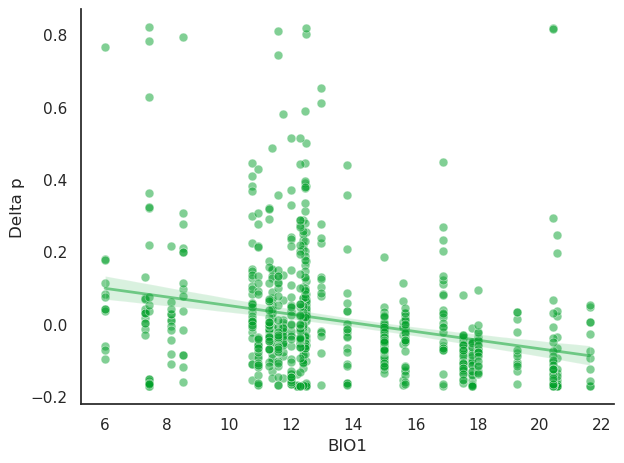

In [342]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'delta_p_block_2_973_andrs' is your DataFrame and it contains all SNPs including the random ones.
df = delta_p_block_2_973_andrs.copy()  # Make sure your DataFrame is correctly loaded and named

snp_id = '2_9812279'
random_snps = randm_list # Replace these with your actual random SNP column names

# Set style to remove grid and despine
sns.set(style="white")  # 'white' style removes the grid and has no background tick marks

# Create scatter plots for random SNPs
for snp in ['2_9812279']:
    ax = sns.scatterplot(data=df, x='bio1', y=snp, alpha=0.5, color='#04a12b', label=None, s=40)
    ax = sns.regplot(data=df, x='bio1', y=snp, color='#04a12b', label=None, scatter=False, line_kws={'lw': 2, 'alpha': 0.5})

# Removing the top and right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Enhancing the plot
ax.set_xlabel('BIO1')
ax.set_ylabel('Delta p')
ax.figure.tight_layout()

plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'delta_p_block_2_973_andrs' is your DataFrame and it contains all SNPs including the random ones.
df = delta_p_block_2_973_andrs.copy()  # Make sure your DataFrame is correctly loaded and named

snp_id = '2_9812279'
random_snps = randm_list # Replace these with your actual random SNP column names

# Set style to remove grid and despine
sns.set(style="white")  # 'white' style removes the grid and has no background tick marks

# Create scatter plots for random SNPs
for snp in random_snps:
    sns.scatterplot(data=df, x='bio1', y=snp, alpha=0.5, color='grey', label=None, s=40)
    sns.regplot(data=df, x='bio1', y=snp, color='grey', label=None, scatter=False, line_kws={'lw': 2, 'alpha': 0.5})

# Highlight the specific SNP
ax = sns.scatterplot(data=df, x='bio1', y=snp_id, alpha=0.3, color='#04a12b', s=40, label=f'SNP {snp_id}')
ax = sns.regplot(data=df, x='bio1', y=snp_id, color='#04a12b', scatter=False, line_kws={'lw': 2, 'alpha': 0.5})

# Removing the top and right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Enhancing the plot
ax.set_xlabel('BIO1')
ax.set_ylabel('Delta p')
ax.figure.tight_layout()

plt.show()



In [188]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'delta_p_block_2_973_andrs' is your DataFrame and it contains all SNPs including the random ones.
df = delta_p_block_2_973_andrs.copy()  # Make sure your DataFrame is correctly loaded and named

snp_id = '2_9754370'
random_snps = randm_list # Replace these with your actual random SNP column names

# Set style to remove grid and despine
sns.set(style="white")  # 'white' style removes the grid and has no background tick marks

# Create scatter plots for random SNPs
for snp in random_snps:
    sns.scatterplot(data=df, x='bio1', y=snp, alpha=0.5, color='grey', label=None, s=40)
    sns.regplot(data=df, x='bio1', y=snp, color='grey', label=None, scatter=False, line_kws={'lw': 2, 'alpha': 0.5})

# Highlight the specific SNP
ax = sns.scatterplot(data=df, x='bio1', y=snp_id, alpha=0.3, color='green', s=40, label=f'SNP {snp_id}')
ax = sns.regplot(data=df, x='bio1', y=snp_id, color='green', scatter=False, line_kws={'lw': 2, 'alpha': 0.5})

# Removing the top and right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Enhancing the plot
ax.set_xlabel('BIO1')
ax.set_ylabel('Delta p')
ax.figure.tight_layout()

plt.show()

,1_1_1,1_1_2,1_1_3,1_1_4,1_1_5,1_1_6,1_1_7,1_1_8,1_1_9,1_1_10,...,60_1_3,60_1_4,60_1_5,60_1_6,60_1_7,60_1_8,60_1_9,60_1_10,60_1_11,60_1_12
1126279,-0.021597,0.007290,0.012600,0.009041,-0.005963,-0.007994,0.036603,-0.007986,0.004697,-0.003438,...,0.116476,-0.027133,-0.043516,-0.044161,0.106725,0.081139,0.122345,-0.039519,-0.044275,-0.037597
1126280,-0.020739,-0.014519,-0.004331,-0.005964,-0.011452,0.005805,-0.004646,0.001319,0.040795,0.000796,...,-0.022253,0.055122,-0.026272,-0.004778,-0.023324,0.100604,0.006393,-0.022467,-0.021925,-0.024253
1126281,0.005666,-0.014027,-0.007829,-0.009436,-0.023588,-0.030313,-0.028629,-0.026938,-0.045531,-0.035136,...,0.036870,-0.055799,-0.056492,-0.043510,-0.018097,-0.053350,-0.048823,-0.026016,-0.057300,-0.052427
1126282,-0.020739,-0.014519,-0.004331,-0.005964,-0.011452,0.005805,-0.004646,0.001319,0.040795,0.000796,...,-0.022253,0.055122,-0.026272,-0.004778,-0.023324,0.100604,0.006393,-0.022467,-0.021925,-0.024253
1126283,0.005549,-0.009195,0.014797,0.014355,-0.007292,0.010053,-0.002635,-0.053246,-0.006264,-0.045135,...,-0.033165,-0.035245,-0.215493,0.062705,0.163016,0.142360,-0.003164,0.177156,-0.066309,-0.076208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1131512,0.002128,0.002731,-0.001250,0.006357,0.033877,0.003084,-0.002205,0.006904,0.032058,0.009385,...,-0.009908,-0.011200,-0.011560,-0.012554,-0.010453,-0.009943,-0.010313,-0.011414,-0.012474,-0.008252
1131513,-0.000548,-0.001011,-0.000812,-0.000833,-0.001015,-0.001193,-0.000925,-0.000408,-0.000694,-0.000119,...,-0.001084,-0.001266,-0.000867,-0.001212,-0.001211,-0.001415,-0.001046,-0.001390,-0.001506,-0.001143
1131514,-0.029786,-0.033267,0.015419,-0.030160,0.053429,-0.003503,0.041647,0.024702,0.009744,0.109462,...,0.173991,0.288604,0.317791,-0.075744,0.154136,0.175317,0.144152,0.170839,0.159129,-0.046501
1131515,-0.002621,0.015592,0.008273,0.000687,-0.008033,0.018272,0.021352,-0.003706,-0.007887,0.005904,...,-0.011492,-0.012921,-0.011942,-0.012398,-0.012849,-0.010509,-0.011990,-0.011198,-0.012971,-0.011558


In [196]:
df

,2_9754370,bio1
0,0.033023,10.743906
1,0.033023,10.743906
2,0.033023,10.743906
3,0.033023,10.743906
4,0.033023,10.743906
...,...,...
20556,0.082984,19.248051
20557,0.082984,19.248051
20558,0.082984,19.248051
20559,0.082984,19.248051


In [204]:
df

,2_9754370,bio1
0,0.033023,10.743906
1,0.033023,10.743906
2,0.033023,10.743906
3,0.033023,10.743906
4,0.033023,10.743906
...,...,...
20556,0.082984,19.248051
20557,0.082984,19.248051
20558,0.082984,19.248051
20559,0.082984,19.248051


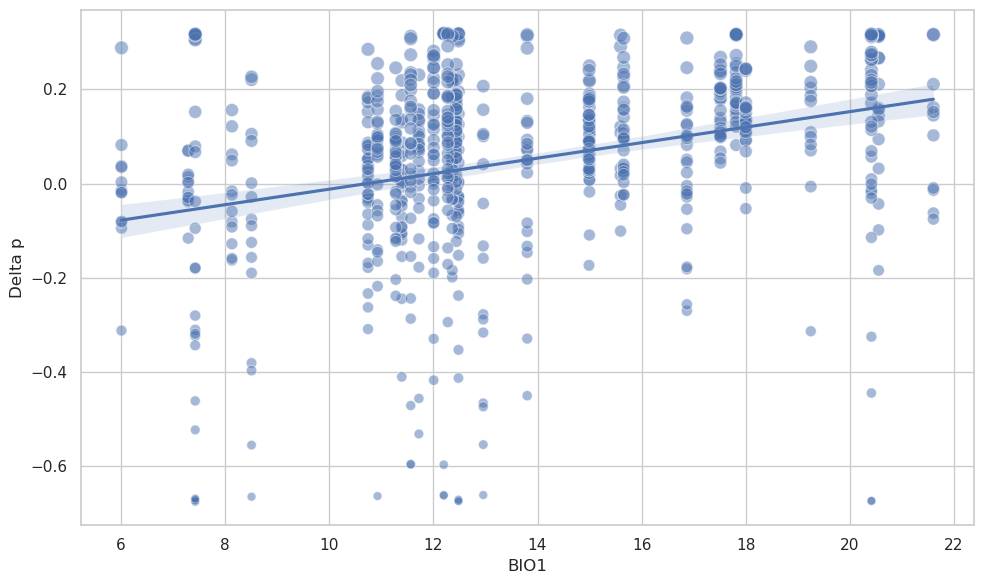

In [291]:
snp_id = '2_9754370'

df = delta_p_block_2_973_andrs[[snp_id, 'bio1']]
# Sample data loading
# df = sns.load_dataset("your_dataset") # Load your dataset here

# Setting aesthetics
#sns.set(style="whitegrid")

# Create a larger figure
plt.figure(figsize=(10, 6))

# Create the regression plot
ax = sns.scatterplot(data=df, x='bio1', y=snp_id, alpha=.5,size=snp_id
                    ,sizes=(40, 100), legend = False)
ax = sns.regplot(data=df, x='bio1', y=snp_id, color='b', marker='o', scatter= None
                )

# Enhancing the plot
ax.set_xlabel('BIO1') #  fontsize=14, labelpad=10)  # BIO1 might be a specific environmental variable
ax.set_ylabel(f'Delta p') #fontsize=14, labelpad=10)
#ax.set_title(f'Regression of SNP {snp_id} on BIO1', fontsize=16, pad=20)
ax.figure.tight_layout()

# Annotate specific points (example)
# ax.annotate('Important Point', xy=(10, 0.2), xytext=(10, 0.3),
#             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show() 

In [ ]:
sns.regplot(snp2_9754370, x = 'bio1', y = '2_9754370')

In [64]:
delta_p_block_2_973.loc['2_9754370', :]

1_2_2      0.052333
1_2_3     -0.130491
1_3_1      0.184678
1_3_4     -0.308944
1_3_5     -0.064686
             ...   
60_1_8     0.175620
60_1_9     0.070342
60_1_10    0.099258
60_1_11    0.215155
60_1_12    0.082984
Name: 2_9754370, Length: 355, dtype: float64

In [ ]:
pd.concat([delta_p, dict_snps])

In [1]:
delta_p

NameError: name 'delta_p' is not defined

In [20]:
gemma_file = '/carnegie/nobackup/scratch/tbellagio/gea_grene-net/idea_fromind_to_pop/1001g/1001_gtrainnongrenet/output/bslmm_nogrenenet_1001g_grenet_climate.param.txt'
gemma = pd.read_csv(gemma_file, sep = '\t')

In [37]:
assoc = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/gea_grene-net/idea_fromind_to_pop/1001g/1001_gtrainnongrenet/output/resultsgemma.assoc.txt', sep = '\t')

In [41]:
assoc = assoc[assoc['p_wald'] < 0.05 / len(assoc)]

In [23]:
clump = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/gea_grene-net/idea_fromind_to_pop/1001g/1001_gtrainnongrenet/clumping_resultsgemma.clumped',sep='\s+')

In [14]:
snp_count_lfmm = defaultdict(int)
for i in range(100):
    file = f'/carnegie/nobackup/scratch/tbellagio/gea_grene-net/leave_1_out/split_number_{i}/delta_p/output_clumping02.clumped'
    snps = pd.read_csv(file, delim_whitespace=True)['SNP']
    for snp in snps:
        snp_count_lfmm[snp] += 1

In [17]:
snps_lfmm = pd.DataFrame(list(snp_count_lfmm.items()), columns=['snp', 'set_number'])

In [24]:
snps_lfmm

,snp,set_number
0,1_194098,13
1,1_852009,4
2,1_900657,5
3,1_903072,11
4,1_991978,17
...,...,...
4814,3_18426838,1
4815,4_12147083,1
4816,4_16320583,1
4817,3_9051095,1


In [27]:
import os

In [30]:
os.listdir('/home/tbellagio/HapFM')

['LICENSE',
 'bin',
 'output_alone_SNPs.txt',
 'output_fine_genomewide_partition.txt',
 'output_306_snpINFO.btmp',
 '.git',
 'output_306_geno_matrix.btmp',
 'examples',
 'README.md',
 'environment.yaml']

In [32]:
#pd.read_csv('/home/tbellagio/HapFM/output_fine_genomewide_partition.txt')

In [34]:
clump

,CHR,F,SNP,BP,P,TOTAL,NSIG,S05,S01,S001,S0001,SP2
0,1,1,1_13083248,13083248,2.530000e-21,82,80,2,0,0,0,NONE
1,1,1,1_10178958,10178958,5.000000e-15,35,6,1,1,24,3,"1_9995669(1),1_10178722(1),1_10178735(1),1_101..."
2,1,1,1_21184001,21184001,1.120000e-14,0,0,0,0,0,0,NONE
3,2,1,2_13506275,13506275,1.540000e-14,174,118,16,15,10,15,"2_13335787(1),2_13466387(1),2_13470422(1),2_13..."
4,1,1,1_15549236,15549236,4.930000e-14,32,31,1,0,0,0,NONE
...,...,...,...,...,...,...,...,...,...,...,...,...
123,2,1,2_19166986,19166986,1.670000e-08,118,87,24,7,0,0,"2_19118362(1),2_19137853(1),2_19161657(1),2_19..."
124,2,1,2_14850334,14850334,1.700000e-08,16,4,0,4,2,6,"2_14616258(1),2_14831185(1),2_14832579(1),2_14..."
125,5,1,5_5610403,5610403,1.700000e-08,35,29,1,5,0,0,"5_5646974(1),5_5646989(1),5_5646991(1),5_56469..."
126,5,1,5_13859287,13859287,1.730000e-08,230,225,3,1,1,0,"5_13783300(1),5_13907797(1)"


In [42]:
assoc

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,logl_H1,l_remle,p_wald
21273,1,1_1480367,1480367,0,T,G,0.011,-1.686882,0.289496,-1453.275,2.310810,8.332257e-09
24753,1,1_1706628,1706628,0,A,G,0.011,-2.507506,0.387224,-1449.790,2.103348,1.693221e-10
25366,1,1_1737504,1737504,0,A,T,0.017,-2.182720,0.365403,-1452.463,2.237417,3.564405e-09
25367,1,1_1737506,1737506,0,A,T,0.018,-2.246671,0.395851,-1454.051,2.267949,1.965705e-08
26575,1,1_1821918,1821918,0,T,C,0.018,-3.210396,0.422477,-1444.682,1.604105,8.781805e-14
...,...,...,...,...,...,...,...,...,...,...,...,...
2261794,5,5_24257224,24257224,0,C,A,0.011,-2.075505,0.353451,-1453.213,2.098978,6.425487e-09
2261878,5,5_24266780,24266780,0,T,C,0.011,-2.075505,0.353451,-1453.213,2.098978,6.425487e-09
2261936,5,5_24271697,24271697,0,G,T,0.011,-2.075505,0.353451,-1453.213,2.098978,6.425487e-09
2262202,5,5_24283153,24283153,0,G,C,0.011,-2.075505,0.353451,-1453.213,2.098978,6.425487e-09


In [43]:
snps_lfmm.merge(assoc,  left_on = 'snp', right_on = 'rs')

,snp,set_number,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,logl_H1,l_remle,p_wald


In [46]:
snps_lfmm = snps_lfmm.sort_values('set_number')

In [48]:
snps_lfmm.to_csv('/carnegie/nobackup/scratch/tbellagio/gea_grene-net/leave_1_out/selected_snps_across_splits.csv', index=None)

In [114]:
# Define the column names as per the GFF3 specification
column_names = ['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute']

# Read the GFF file
gff_data = pd.read_csv('TAIR10_GFF3_genes_transposons.gff', sep='\t', comment='#', names=column_names)

In [ ]:
> head(n=2, enshuman::hg38)
  chrom gene_start gene_end gene_symbol                biotype
1     1     182696   184174    DDX11L17 unprocessed_pseudogene
2     1    3069168  3438621      PRDM16         protein_coding
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          exon_chromstart
1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      182696,183132,183494,183740,183981
2 3069168,3186125,3244087,3385149,3396491,3402791,3404739,3405495,3411384,3414560,3417828,3418667,3425581,3426051,3430872,3433677,3069183,3186125,3069197,3186125,3244087,3385152,3396491,3402791,3404739,3405495,3411384,3414560,3417828,3418667,3425581,3426051,3430872,3431966,3433734,3069211,3186125,3244087,3385149,3396491,3402791,3404739,3405495,3411384,3414563,3417828,3418667,3425581,3426051,3430872,3433677,3069203,3186125,3244087,3385152,3396491,3402791,3404739,3405495,3411384,3414560,3417828,3418667,3425581,3426051,3430872,3431966,3433677,3237931,3244087,3385152,3396491,3402791,3404739,3405495,3411384,3414560,3417828,3418667,3425581,3426051,3430872,3431966,3433677,3244132,3385152,3386676,3396491,3402791,3404739,3405495,3411384,3414563,3417828,3418667,3425581,3426051,3430872,3431966,3433677,3424919,3425581,3426051,3430872,3433677,3425216,3426051
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            exon_chromend
1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      182746,183216,183571,183901,184174
2 3069296,3186474,3244137,3385286,3396593,3402998,3404886,3405648,3412800,3414647,3417997,3418744,3425750,3426225,3431108,3434342,3069296,3186591,3069296,3186474,3244137,3385286,3396593,3402998,3404886,3405648,3412800,3414647,3417997,3418744,3425750,3426225,3431108,3432140,3435421,3069296,3186474,3244137,3385286,3396593,3402998,3404886,3405648,3412800,3414647,3417997,3418744,3425750,3426225,3431108,3434342,3069296,3186474,3244137,3385286,3396593,3402998,3404886,3405648,3412800,3414647,3417997,3418744,3425750,3426225,3431108,3432140,3438621,3238095,3244137,3385286,3396593,3402998,3404886,3405648,3412800,3414647,3417997,3418744,3425750,3426225,3431108,3432140,3433925,3244137,3385286,3386918,3396593,3402998,3404886,3405648,3412800,3414647,3417997,3418744,3425750,3426225,3431108,3432140,3434293,3425059,3425750,3426225,3431108,3434095,3425750,3426072

In [ ]:
# Adjusted function to correctly map exons to genes by considering mRNA as intermediates
def parse_gff3(filepath):
    # Initialize lists to hold gene, mRNA, and exon data
    gene_data = []
    mrna_data = []
    exon_data = []

    # Read through the file and parse lines
    with open(filepath, 'r') as file:
        for line in file:
            if line.startswith('#'):
                continue
            parts = line.strip().split('\t')
            chrom, source, feature, start, end, score, strand, phase, attributes = parts
            attr_dict = {item.split('=')[0]: item.split('=')[1] for item in attributes.split(';') if '=' in item}
            
            # Process gene, mRNA, and exon entries
            if feature == 'gene':
                gene_id = attr_dict.get('ID', '')
                gene_name = attr_dict.get('Name', gene_id.split('.')[0])
                biotype = attr_dict.get('Note', 'unknown')
                gene_data.append((chrom, start, end, gene_name, biotype, gene_id))
            elif feature == 'mRNA':
                mrna_id = attr_dict.get('ID', '')
                parent_id = attr_dict.get('Parent', '')
                mrna_data.append((parent_id, mrna_id))
            elif feature == 'exon' and 'Parent' in attr_dict:
                parent_id = attr_dict['Parent']
                exon_data.append((parent_id, start, end))

    # Convert lists to DataFrames
    gene_df = pd.DataFrame(gene_data, columns=['chrom', 'gene_start', 'gene_end', 'gene_symbol', 'biotype', 'gene_id'])
    mrna_df = pd.DataFrame(mrna_data, columns=['gene_id', 'mrna_id'])
    exon_df = pd.DataFrame(exon_data, columns=['mrna_id', 'exon_start', 'exon_end'])

    # Link mRNA to genes and exons to mRNA
    merged_df = gene_df.merge(mrna_df, on='gene_id').merge(exon_df, on='mrna_id')
    merged_df['exon_chromstart'] = merged_df.groupby('gene_id')['exon_start'].transform(lambda x: ','.join(x))
    merged_df['exon_chromend'] = merged_df.groupby('gene_id')['exon_end'].transform(lambda x: ','.join(x))

    # Drop duplicates and unnecessary columns
    final_df = merged_df.drop(['mrna_id', 'exon_start', 'exon_end'], axis=1).drop_duplicates()
    
    return final_df

# Parse the GFF3 file with the final adjustments
gff3_formatted = parse_gff3('TAIR10_GFF3_genes_transposons.gff')

gff3_formatted['chrom'].unique()

## discard the mithocondrial and chloroplast 
gff3_formatted = gff3_formatted[gff3_formatted['chrom'].isin(['Chr1', 'Chr2', 'Chr3', 'Chr4', 'Chr5'])]

gff3_formatted['chrom'] = gff3_formatted['chrom'].str.replace('Chr', '').astype(int)

gff3_formatted.to_csv('TAIR10_GFF3_genes_transposons_formatted4topr.csv')

In [138]:
gff3_formatted

,chrom,gene_start,gene_end,gene_symbol,biotype,gene_id,exon_chromstart,exon_chromend
0,1,3631,5899,AT1G01010,protein_coding_gene,AT1G01010,"3631,3996,4486,4706,5174,5439","3913,4276,4605,5095,5326,5899"
6,1,5928,8737,AT1G01020,protein_coding_gene,AT1G01020,"8571,8417,8236,7942,7762,7564,7384,7157,6437,5...","8737,8464,8325,7987,7835,7649,7450,7232,7069,6..."
24,1,11649,13714,AT1G01030,protein_coding_gene,AT1G01030,"13335,11649","13714,13173"
26,1,23146,31227,AT1G01040,protein_coding_gene,AT1G01040,"23146,24542,24752,25041,25524,25825,26081,2629...","24451,24655,24962,25435,25743,25997,26203,2645..."
66,1,31170,33153,AT1G01050,protein_coding_gene,AT1G01050,"33029,32547,32431,32282,32088,31933,31693,3152...","33153,32670,32459,32347,32195,31998,31813,3160..."
...,...,...,...,...,...,...,...,...
207189,5,26959569,26960323,AT5G67600,protein_coding_gene,AT5G67600,"26960181,26959937,26959569","26960323,26960093,26959799"
207192,5,26960931,26963638,AT5G67610,protein_coding_gene,AT5G67610,"26963509,26963122,26962863,26962648,26962503,2...","26963638,26963335,26963020,26962793,26962562,2..."
207212,5,26964770,26965996,AT5G67620,protein_coding_gene,AT5G67620,"26965468,26965198,26964770","26965996,26965379,26965004"
207215,5,26967381,26969394,AT5G67630,protein_coding_gene,AT5G67630,"26968558,26967381","26969394,26968195"


In [ ]:
## teh gene from the highest peak of lfmm 
AT2G23270

In [192]:
gff3_formatted[gff3_formatted['gene_id'] == 'AT2G23270']

,chrom,gene_start,gene_end,gene_symbol,biotype,gene_id,exon_chromstart,exon_chromend
67118,2,9903215,9903845,AT2G23270,protein_coding_gene,AT2G23270,9903215,9903845


In [ ]:
9903215

In [89]:
# Extract only gene-related features from the annotation data
genes = gff_data[gff_data['feature'] == 'gene']

In [91]:
# Extract relevant information from the gene description in column 8
genes['gene_id'] = genes['attribute'].str.extract(r'ID=([^;]+)')

In [94]:
lfmm_result_sign = lfmm_result[lfmm_result['significant']==True]

In [95]:
# Parse the chromosome and position from SNP IDs in the GWAS results
lfmm_result_sign['chromosome'] = lfmm_result_sign['snp_id'].apply(lambda x: 'Chr' + x.split('_')[0])
lfmm_result_sign['position'] = lfmm_result_sign['snp_id'].apply(lambda x: int(x.split('_')[1]))

/tmp/ipykernel_48848/400522321.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lfmm_result_sign['chromosome'] = lfmm_result_sign['snp_id'].apply(lambda x: 'Chr' + x.split('_')[0])
/tmp/ipykernel_48848/400522321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lfmm_result_sign['position'] = lfmm_result_sign['snp_id'].apply(lambda x: int(x.split('_')[1]))


In [98]:
# Convert chromosome and position data in genes dataframe to facilitate comparison
genes['start'] = genes['start'].astype(int)
genes['end'] = genes['end'].astype(int)

In [99]:
genes

,seqname,source,feature,start,end,score,strand,frame,attribute,gene_id
1,Chr1,TAIR10,gene,3631,5899,.,+,.,ID=AT1G01010;Note=protein_coding_gene;Name=AT1...,AT1G01010
18,Chr1,TAIR10,gene,5928,8737,.,-,.,ID=AT1G01020;Note=protein_coding_gene;Name=AT1...,AT1G01020
63,Chr1,TAIR10,gene,11649,13714,.,-,.,ID=AT1G01030;Note=protein_coding_gene;Name=AT1...,AT1G01030
72,Chr1,TAIR10,gene,23146,31227,.,+,.,ID=AT1G01040;Note=protein_coding_gene;Name=AT1...,AT1G01040
161,Chr1,TAIR10,gene,28500,28706,.,+,.,ID=AT1G01046;Note=miRNA;Name=AT1G01046,AT1G01046
...,...,...,...,...,...,...,...,...,...,...
590243,ChrM,TAIR10,gene,360717,361052,.,-,.,ID=ATMG01370;Note=protein_coding_gene;Name=ATM...,ATMG01370
590248,ChrM,TAIR10,gene,361062,361179,.,-,.,ID=ATMG01380;Note=rRNA;Name=ATMG01380,ATMG01380
590251,ChrM,TAIR10,gene,361350,363284,.,-,.,ID=ATMG01390;Note=rRNA;Name=ATMG01390,ATMG01390
590254,ChrM,TAIR10,gene,363725,364042,.,+,.,ID=ATMG01400;Note=protein_coding_gene;Name=ATM...,ATMG01400


In [100]:
# Function to find closest gene for each significant SNP
def find_closest_gene(snp_chrom, snp_pos):
    # Filter genes to the same chromosome
    possible_genes = genes[(genes['seqname'] == snp_chrom)]
    # Find gene with the closest start or end position to the SNP
    possible_genes['distance_to_snp'] = possible_genes.apply(
        lambda x: min(abs(x['start'] - snp_pos), abs(x['end'] - snp_pos)), axis=1)
    # Return the gene with the minimum distance to the SNP
    closest_gene = possible_genes.loc[possible_genes['distance_to_snp'].idxmin()]
    return closest_gene['gene_id'], closest_gene['distance_to_snp']

In [101]:
# Apply the function to find the closest gene for each significant SNP
lfmm_result_sign['closest_gene'], lfmm_result_sign['gene_distance'] = zip(
    *lfmm_result_sign.apply(lambda x: find_closest_gene(x['chromosome'], x['position']), axis=1))

/tmp/ipykernel_48848/4202611497.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lfmm_result_sign['closest_gene'], lfmm_result_sign['gene_distance'] = zip(
/tmp/ipykernel_48848/4202611497.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lfmm_result_sign['closest_gene'], lfmm_result_sign['gene_distance'] = zip(


In [103]:
lfmm_result_sign.to_csv('lfmm_result_sign.csv')

In [106]:
genes

,seqname,source,feature,start,end,score,strand,frame,attribute,gene_id
1,Chr1,TAIR10,gene,3631,5899,.,+,.,ID=AT1G01010;Note=protein_coding_gene;Name=AT1...,AT1G01010
18,Chr1,TAIR10,gene,5928,8737,.,-,.,ID=AT1G01020;Note=protein_coding_gene;Name=AT1...,AT1G01020
63,Chr1,TAIR10,gene,11649,13714,.,-,.,ID=AT1G01030;Note=protein_coding_gene;Name=AT1...,AT1G01030
72,Chr1,TAIR10,gene,23146,31227,.,+,.,ID=AT1G01040;Note=protein_coding_gene;Name=AT1...,AT1G01040
161,Chr1,TAIR10,gene,28500,28706,.,+,.,ID=AT1G01046;Note=miRNA;Name=AT1G01046,AT1G01046
...,...,...,...,...,...,...,...,...,...,...
590243,ChrM,TAIR10,gene,360717,361052,.,-,.,ID=ATMG01370;Note=protein_coding_gene;Name=ATM...,ATMG01370
590248,ChrM,TAIR10,gene,361062,361179,.,-,.,ID=ATMG01380;Note=rRNA;Name=ATMG01380,ATMG01380
590251,ChrM,TAIR10,gene,361350,363284,.,-,.,ID=ATMG01390;Note=rRNA;Name=ATMG01390,ATMG01390
590254,ChrM,TAIR10,gene,363725,364042,.,+,.,ID=ATMG01400;Note=protein_coding_gene;Name=ATM...,ATMG01400


In [109]:
lfmm_result_sign = lfmm_result_sign.merge(genes, left_on = 'closest_gene' , right_on = 'gene_id')

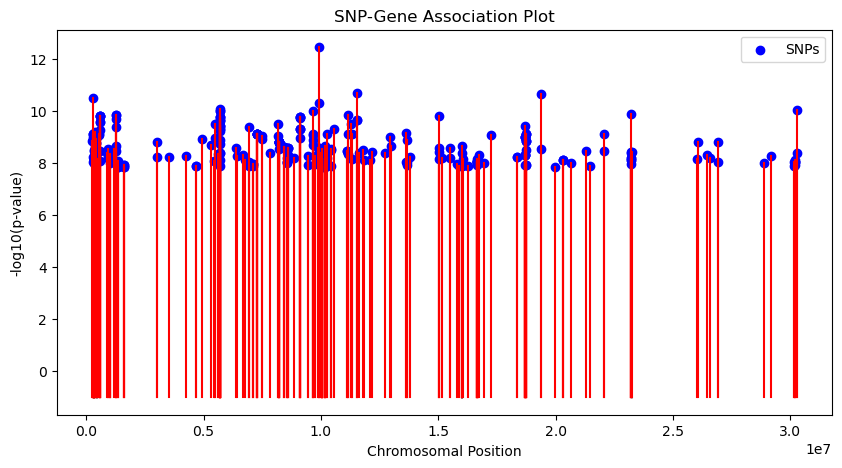

In [110]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load your data
data = lfmm_result_sign.copy()
# Convert p-values to -log10(p-value)
data['neg_log10_p_value'] = -np.log10(data['p_value'])

# Create the plot
plt.figure(figsize=(10, 5))

# Plot each SNP
plt.scatter(data['position'], data['neg_log10_p_value'], color='blue', label='SNPs')

# Add gene structures
for _, row in data.iterrows():
    plt.hlines(y=-1, xmin=row['start'], xmax=row['end'], color='gray', lw=2)

# Draw connections between significant SNPs and their closest genes
for _, row in data.iterrows():
    if row['significant']:  # Assuming a 'significant' column to identify significant SNPs
        plt.plot([row['position'], row['position']], [row['neg_log10_p_value'], -1], 'r-')

plt.xlabel('Chromosomal Position')
plt.ylabel('-log10(p-value)')
plt.title('SNP-Gene Association Plot')
plt.legend()
plt.show()
